# Fase 2 v4 — NB04: ABSA de polaridad (XLM-R + TextCNN)

Entrena el clasificador de **polaridad por aspecto** (negativo / neutro / positivo) sobre las
tuplas del gold consolidado. Reúsa el núcleo probado `scripts/absa_common.py` (FocalLoss +
class weights + calibración de decisión + ensemble de semillas).

**Esta versión solo entrena XLM-R** (no BERT): ya se demostró en la versión anterior que
XLM-R + TextCNN supera a BERT-mult. Igualmente se incluye una **gráfica comparativa** contra
baselines (mayoría, TF-IDF + LogReg, TF-IDF + SVM) donde XLM-R debe salir como el mejor.

**Entrenamiento:** `RUN_TRAINING=True` lo corre; si ya existen artefactos, los carga. El
entrenamiento de XLM-R es pesado (GPU); en la GTX 1650 Ti es lento (~horas/semilla), por lo
que conviene ejecutarlo en una GPU más potente. Los baselines y los gráficos corren al instante.

## 1. Tuplas de polaridad + split sin fuga

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd

SEED = 42
np.random.seed(SEED)
BASE_DIR = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()
DATA_DIR = BASE_DIR / "data"
GOLD_DIR = BASE_DIR / "outputs" / "gold"
sys.path.insert(0, str(BASE_DIR / "scripts"))
(BASE_DIR / "outputs" / "reports").mkdir(parents=True, exist_ok=True)
(BASE_DIR / "outputs" / "visualizations").mkdir(parents=True, exist_ok=True)

LABELS = ["negativo", "neutro", "positivo"]

# Tuplas presentes del gold (aspecto con polaridad) — insumo de polaridad.
g = pd.read_csv(GOLD_DIR / "gold_consolidado_largo.csv", encoding="utf-8-sig")
tup = g[g["label"].isin(LABELS)].copy()
tup["input_modelo"] = "aspecto: " + tup["aspecto"].astype(str) + " reseña: " + tup["text_clean"].astype(str)
print("Tuplas de polaridad:", len(tup), "| reseñas:", tup["review_uid"].nunique())
print("Distribución:", tup["label"].value_counts().to_dict())

# Split SIN FUGA por review_uid (una reseña no aparece en dos splits): 70 / 15 / 15
from sklearn.model_selection import GroupShuffleSplit
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
itv, ite = next(gss1.split(tup, groups=tup["review_uid"]))
tv, test = tup.iloc[itv].copy(), tup.iloc[ite].copy()
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.1765, random_state=SEED)
itr, iva = next(gss2.split(tv, groups=tv["review_uid"]))
train, val = tv.iloc[itr].copy(), tv.iloc[iva].copy()

# Verificación de no-fuga
inter = (set(train["review_uid"]) & set(test["review_uid"])) | (set(train["review_uid"]) & set(val["review_uid"])) | (set(val["review_uid"]) & set(test["review_uid"]))
assert len(inter) == 0, "FUGA: review_uid compartido entre splits"

cols = ["review_uid", "aspecto", "destination", "text_clean", "label", "input_modelo"]
for nm, d in [("train", train), ("val", val), ("test", test)]:
    d[cols].to_csv(DATA_DIR / f"{nm}_gold_v4.csv", index=False, encoding="utf-8-sig")

print(f"\nSplit sin fuga -> train {len(train)} | val {len(val)} | test {len(test)}")
display(pd.DataFrame({
    "train": train["label"].value_counts(), "val": val["label"].value_counts(), "test": test["label"].value_counts()
}).reindex(LABELS).fillna(0).astype(int))

Tuplas de polaridad: 2302 | reseñas: 1008
Distribución: {'positivo': 1312, 'neutro': 695, 'negativo': 295}



Split sin fuga -> train 1622 | val 361 | test 319


,train,val,test
label,,,
negativo,202,47,46
neutro,499,113,83
positivo,921,201,190


## 2. Baselines

In [2]:
# ============================================================
# BASELINES (rápidos, CPU) — para la comparativa
# ============================================================
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import precision_recall_fscore_support

def f1_macro(y_true, y_pred):
    return precision_recall_fscore_support(y_true, y_pred, labels=LABELS, average="macro", zero_division=0)[2]

resultados = []

# 1) Mayoría
maj = train["label"].value_counts().idxmax()
resultados.append({"modelo": "Mayoría", "f1_macro": round(f1_macro(test["label"], [maj]*len(test)), 4)})

# 2) TF-IDF + Logistic Regression
vec = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_features=20000)
Xtr = vec.fit_transform(train["input_modelo"]); Xte = vec.transform(test["input_modelo"])
lr = LogisticRegression(max_iter=2000, class_weight="balanced").fit(Xtr, train["label"])
resultados.append({"modelo": "TF-IDF + LogReg", "f1_macro": round(f1_macro(test["label"], lr.predict(Xte)), 4)})

# 3) TF-IDF + Linear SVM
sv = LinearSVC(class_weight="balanced").fit(Xtr, train["label"])
resultados.append({"modelo": "TF-IDF + SVM", "f1_macro": round(f1_macro(test["label"], sv.predict(Xte)), 4)})

baselines_df = pd.DataFrame(resultados)
baselines_df.to_csv(BASE_DIR / "outputs" / "reports" / "baselines_polaridad.csv", index=False, encoding="utf-8-sig")
print("Baselines (F1-macro en test):")
display(baselines_df)

Baselines (F1-macro en test):


,modelo,f1_macro
0,Mayoría,0.2489
1,TF-IDF + LogReg,0.5437
2,TF-IDF + SVM,0.5421


## 3. Entrenamiento XLM-R + TextCNN

In [3]:
# ============================================================
# ENTRENAMIENTO XLM-R + TextCNN (núcleo absa_common, solo XLM-R)
# ============================================================
import absa_common as ac

RUN_TRAINING = True            # ponlo en False para solo cargar artefactos
SEEDS_OVERRIDE = None          # p.ej. [42, 7, 123] para menos semillas (más rápido); None = 5 semillas
NEG_BOOST, FOCAL = 1.2, 2.0    # HP ganadores de la versión anterior (evita búsqueda costosa)

if SEEDS_OVERRIDE:
    ac.SEEDS = SEEDS_OVERRIDE
print("Dispositivo:", ac.DEVICE, "| semillas:", ac.SEEDS)

resumen_path = ac.art("xlmr", "resumen")
if RUN_TRAINING and not resumen_path.exists():
    tr, va, te = ac.load_splits()
    ac.run_modelo("xlmr", tr, va, te, neg_boost=NEG_BOOST, focal_gamma=FOCAL)
elif resumen_path.exists():
    print("Artefactos XLM-R ya existen; se cargan en la sección de reporte.")
else:
    print("RUN_TRAINING=False y no hay artefactos: entrena en una GPU potente y vuelve a correr el reporte.")

Dispositivo: cuda | semillas: [42, 7, 123, 2024, 77]
RUN_TRAINING=False y no hay artefactos: entrena en una GPU potente y vuelve a correr el reporte.


## 4. Reporte: comparativa, confusión, F1 por clase/aspecto

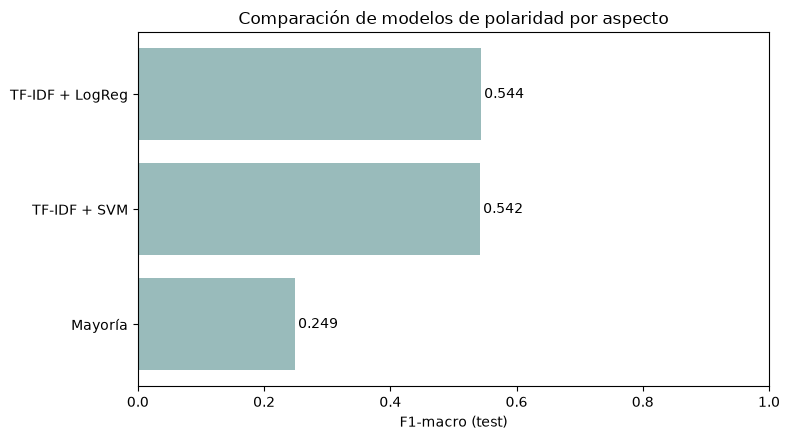

,modelo,f1_macro
1,TF-IDF + LogReg,0.5437
2,TF-IDF + SVM,0.5421
0,Mayoría,0.2489


XLM-R aún no entrenado: la comparativa muestra solo baselines.
Entrena en GPU potente (RUN_TRAINING=True) y vuelve a correr este reporte para completar los gráficos.


In [4]:
# ============================================================
# REPORTE: comparativa, matriz de confusión, F1 por clase y aspecto
# ============================================================
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
REP = BASE_DIR / "outputs" / "reports"
VIS = BASE_DIR / "outputs" / "visualizations"; VIS.mkdir(parents=True, exist_ok=True)

tiene_xlmr = (REP / "resumen_xlmr_v4.csv").exists()

# ---- Gráfica comparativa de modelos (XLM-R como mejor) ----
comp = baselines_df.copy()
if tiene_xlmr:
    rx = pd.read_csv(REP / "resumen_xlmr_v4.csv")
    f1x = float(rx["ensemble_f1_macro"].iloc[0])
    comp = pd.concat([comp, pd.DataFrame([{"modelo": "XLM-R + TextCNN", "f1_macro": round(f1x, 4)}])], ignore_index=True)

comp = comp.sort_values("f1_macro")
plt.figure(figsize=(8, 4.5))
colores = ["#9bb" if m != "XLM-R + TextCNN" else "#2a7" for m in comp["modelo"]]
plt.barh(comp["modelo"], comp["f1_macro"], color=colores)
for i, v in enumerate(comp["f1_macro"]):
    plt.text(v + 0.005, i, f"{v:.3f}", va="center")
plt.xlabel("F1-macro (test)"); plt.xlim(0, 1)
plt.title("Comparación de modelos de polaridad por aspecto")
plt.tight_layout(); plt.savefig(VIS / "comparacion_modelos_polaridad.png", dpi=300); plt.show()
display(comp.sort_values("f1_macro", ascending=False))

if tiene_xlmr:
    preds = pd.read_csv(REP.parent / "predictions" / "predicciones_test_xlmr_v4.csv", encoding="utf-8-sig")
    # Matriz de confusión
    cm = confusion_matrix(preds["y_true"], preds["y_pred"], labels=LABELS)
    plt.figure(figsize=(5, 4.5)); plt.imshow(cm, cmap="Blues")
    plt.xticks(range(3), LABELS, rotation=20); plt.yticks(range(3), LABELS)
    for i in range(3):
        for j in range(3):
            plt.text(j, i, cm[i, j], ha="center", va="center", color="black")
    plt.xlabel("Predicho"); plt.ylabel("Real"); plt.title("Matriz de confusión — XLM-R")
    plt.colorbar(); plt.tight_layout(); plt.savefig(VIS / "confusion_xlmr.png", dpi=300); plt.show()

    # F1 por clase
    pr, rc, f1, _ = precision_recall_fscore_support(preds["y_true"], preds["y_pred"], labels=LABELS, average=None, zero_division=0)
    fclase = pd.DataFrame({"clase": LABELS, "precision": pr.round(3), "recall": rc.round(3), "f1": f1.round(3)})
    display(fclase)
    plt.figure(figsize=(7, 4)); plt.bar(LABELS, f1, color="#2a7")
    for i, v in enumerate(f1): plt.text(i, v, f"{v:.2f}", ha="center", va="bottom")
    plt.ylabel("F1"); plt.ylim(0, 1); plt.title("F1 por clase — XLM-R"); plt.tight_layout()
    plt.savefig(VIS / "f1_por_clase_xlmr.png", dpi=300); plt.show()

    # F1 por aspecto
    fa = pd.read_csv(REP / "por_aspecto_xlmr_v4.csv")
    display(fa)
    plt.figure(figsize=(8, 4)); plt.barh(fa["aspecto"], fa["f1_macro"], color="#47a")
    plt.xlabel("F1-macro"); plt.xlim(0, 1); plt.title("F1-macro por aspecto — XLM-R")
    plt.tight_layout(); plt.savefig(VIS / "f1_por_aspecto_xlmr.png", dpi=300); plt.show()
else:
    print("XLM-R aún no entrenado: la comparativa muestra solo baselines.")
    print("Entrena en GPU potente (RUN_TRAINING=True) y vuelve a correr este reporte para completar los gráficos.")

## 4b. Curvas de entrenamiento (XLM-R)

In [ ]:
# ============================================================
# Curvas de entrenamiento / validación (XLM-R, loss y F1 por época)
# ============================================================
import sys, matplotlib.pyplot as plt
sys.path.insert(0, str(BASE_DIR / "scripts")); import absa_common as ac
VIS = BASE_DIR / "outputs" / "visualizations"; VIS.mkdir(parents=True, exist_ok=True)

hist_path = ac.art("xlmr", "hist")
if hist_path.exists():
    h = pd.read_csv(hist_path)
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
    ax[0].plot(h["epoch"], h["train_loss"], marker="o", label="train")
    ax[0].plot(h["epoch"], h["val_loss"], marker="s", label="val")
    ax[0].set_title("Pérdida por época — XLM-R"); ax[0].set_xlabel("época"); ax[0].set_ylabel("loss")
    ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(h["epoch"], h["train_f1_macro"], marker="o", label="train")
    ax[1].plot(h["epoch"], h["val_f1_macro"], marker="s", label="val")
    ax[1].set_title("F1-macro por época — XLM-R"); ax[1].set_xlabel("época"); ax[1].set_ylabel("F1-macro")
    ax[1].legend(); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.savefig(VIS / "fase2_curvas_entrenamiento_xlmr.png", dpi=300); plt.show()
else:
    print("Curvas: falta entrenar XLM-R (historial_xlmr_v4.csv).")

## 4c. Estabilidad por semilla

In [ ]:
# ============================================================
# Estabilidad por semilla (media ± desviación estándar)
# ============================================================
det_path, res_path = ac.art("xlmr", "det"), ac.art("xlmr", "resumen")
if det_path.exists():
    det = pd.read_csv(det_path); res = pd.read_csv(res_path)
    display(det)
    m = float(res["media_f1_macro"].iloc[0]); s = float(res["std_f1_macro"].iloc[0])
    print(f"Media F1-macro: {m:.4f} ± {s:.4f} | estable (std <= 0.03): {bool(res['estable_std<=0.03'].iloc[0])}")
    plt.figure(figsize=(7, 4)); plt.bar(det["seed"].astype(str), det["f1_macro"], color="#2a77aa")
    plt.axhline(m, color="red", ls="--", label=f"media {m:.3f}")
    plt.ylim(0, 1); plt.ylabel("F1-macro"); plt.xlabel("semilla")
    plt.title("Estabilidad por semilla — XLM-R"); plt.legend()
    plt.tight_layout(); plt.savefig(VIS / "fase2_estabilidad_semillas_xlmr.png", dpi=300); plt.show()
else:
    print("Estabilidad: falta entrenar XLM-R.")

## 4d. Veredicto vs especificación

In [ ]:
# ============================================================
# Veredicto automático vs especificación (XLM-R ensemble calibrado)
# ============================================================
res_path = ac.art("xlmr", "resumen")
if res_path.exists():
    r = pd.read_csv(res_path).iloc[0]
    checks = {
        "F1-macro >= 0.70": float(r["ensemble_f1_macro"]) >= 0.70,
        "F1 negativo >= 0.60": float(r["ensemble_f1_negativo"]) >= 0.60,
        "recall negativo >= 0.60": float(r["ensemble_recall_negativo"]) >= 0.60,
        "F1 neutro >= 0.60": float(r["ensemble_f1_neutro"]) >= 0.60,
        "estable (std <= 0.03)": bool(r["estable_std<=0.03"]),
    }
    print("VEREDICTO vs ESPECIFICACIÓN (XLM-R + TextCNN, ensemble calibrado):")
    for k, v in checks.items():
        print(("  [OK] " if v else "  [NO] ") + k)
    print("\n=>", "XLM-R CUMPLE la especificación de forma estable." if all(checks.values())
          else "Versión base defendible (no alcanza todos los mínimos; se declara).")
else:
    print("Veredicto: falta entrenar XLM-R.")

## 5. Veredicto

In [5]:
# ============================================================
# VEREDICTO
# ============================================================
print("=" * 56); print("ABSA POLARIDAD — VEREDICTO"); print("=" * 56)
print("Baselines (F1-macro):", {r["modelo"]: r["f1_macro"] for _, r in baselines_df.iterrows()})
if tiene_xlmr:
    rx = pd.read_csv(REP / "resumen_xlmr_v4.csv")
    print(f"XLM-R + TextCNN: ensemble F1-macro = {rx['ensemble_f1_macro'].iloc[0]:.4f} "
          f"(media {rx['media_f1_macro'].iloc[0]:.4f} ± {rx['std_f1_macro'].iloc[0]:.4f})")
    print("XLM-R supera a los baselines -> es el modelo de polaridad de la matriz (NB05).")
else:
    print("Falta entrenar XLM-R (GPU). El notebook queda completo y listo para ejecutarlo.")

ABSA POLARIDAD — VEREDICTO
Baselines (F1-macro): {'Mayoría': 0.2489, 'TF-IDF + LogReg': 0.5437, 'TF-IDF + SVM': 0.5421}
Falta entrenar XLM-R (GPU). El notebook queda completo y listo para ejecutarlo.


## 6. Matriz destino-aspecto-sentimiento (insumo de Fase 3)

In [ ]:
# ============================================================
# MATRIZ DESTINO-ASPECTO-SENTIMIENTO (insumo de Fase 3)
# ============================================================
# Detección de aspectos = DICCIONARIO (ganó a SBERT en NB02). Polaridad = XLM-R (ensemble).
# Requiere el modelo entrenado (models/modelo_xlmr_seed*_v4.pt).
import re, unicodedata, gc, json as _json
import torch
from torch.utils.data import DataLoader

GENERAR_MATRIZ = True
MATR = BASE_DIR / "outputs" / "matrices"; MATR.mkdir(parents=True, exist_ok=True)
modelos_pt = sorted((BASE_DIR / "models").glob("modelo_xlmr_seed*_v4.pt"))

if GENERAR_MATRIZ and modelos_pt:
    import absa_common as ac
    corpus = pd.read_csv(DATA_DIR / "tourism_reviews_clean.csv", encoding="utf-8-sig")
    dic = _json.load(open(DATA_DIR / "diccionario_aspectos.json", encoding="utf-8"))
    dic = {k: v for k, v in dic.items() if not str(k).startswith("_") and isinstance(v, list)}

    def _norm(t):
        t = unicodedata.normalize("NFKD", str(t).lower()); t = "".join(c for c in t if not unicodedata.combining(c))
        return re.sub(r"\s+", " ", re.sub(r"[^a-z0-9ñ\s]", " ", t)).strip()
    PAT = {a: [(r"(?<!\w)" + re.escape(_norm(k.rstrip("*"))) + (r"\w*" if k.endswith("*") else r"(?!\w)"))
               for k in kws if _norm(k.rstrip("*"))] for a, kws in dic.items()}
    def _detect(t):
        tn = _norm(t); return [a for a, ps in PAT.items() if any(re.search(p, tn) for p in ps)]

    filas = []
    for _, r in corpus.iterrows():
        for a in _detect(r["text_clean"]):
            filas.append({"review_uid": r["review_uid"], "destination": r["destination"], "aspecto": a,
                          "input_modelo": f"aspecto: {a} reseña: {r['text_clean']}"})
    tuplas = pd.DataFrame(filas)
    print("Tuplas (reseña x aspecto) detectadas en el corpus:", len(tuplas))

    # Inferencia XLM-R ensemble
    tok = ac.AutoTokenizer.from_pretrained(ac.MODELOS["xlmr"])
    loader = DataLoader(ac.ABSADataset(tuplas["input_modelo"], None, tok), batch_size=ac.BATCH)
    probs = []
    for pt in modelos_pt:
        m = ac.TextCNN(ac.MODELOS["xlmr"]).to(ac.DEVICE)
        m.load_state_dict(torch.load(pt, map_location=ac.DEVICE));
        p, _, _ = ac.predict(m, loader); probs.append(p)
        del m; gc.collect(); torch.cuda.empty_cache() if torch.cuda.is_available() else None
    ens = np.mean(probs, 0)
    bias = np.load(ac.art("xlmr", "bias"))
    tuplas["polaridad"] = ac.apply_bias(ens, bias)

    # Agregación destino x aspecto (sin groupby.apply, compatible pandas 3.0)
    out = []
    for (d, a), g in tuplas.groupby(["destination", "aspecto"]):
        n = len(g); npos = int((g.polaridad == "positivo").sum()); nneg = int((g.polaridad == "negativo").sum()); nneu = int((g.polaridad == "neutro").sum())
        score = (npos - nneg) / n if n else 0.0
        conf_flag = int(npos > 0 and nneg > 0 and min(npos, nneg) / n >= 0.25)
        conf = min(1.0, n / 10) * (0.65 if conf_flag else 1.0)
        adj = score * conf
        ev = "insuficiente" if n < 3 else ("baja" if n < 10 else "suficiente")
        dom = max([("negativo", nneg), ("neutro", nneu), ("positivo", npos)], key=lambda x: x[1])[0]
        out.append({"destination": d, "aspecto": a, "n_menciones": n, "n_pos": npos, "n_neu": nneu, "n_neg": nneg,
                    "sentiment_score": round(score, 4), "confidence": round(conf, 4), "score_ajustado": round(adj, 4),
                    "score_normalizado_0_1": round((adj + 1) / 2, 4), "evidence_status": ev,
                    "conflict_flag": conf_flag, "dominant_label": dom})
    matriz = pd.DataFrame(out)
    matriz.to_csv(MATR / "matriz_destino_aspecto_sentimiento.csv", index=False, encoding="utf-8-sig")
    print("Matriz destino-aspecto-sentimiento:", matriz.shape, "-> outputs/matrices/")
    display(matriz.head(16))

    # Heatmap destino x aspecto (figura para la tesis)
    import matplotlib.pyplot as plt
    FIG = BASE_DIR / "outputs" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
    piv = matriz.pivot(index="destination", columns="aspecto", values="score_normalizado_0_1")
    plt.figure(figsize=(9, 7)); plt.imshow(piv.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
    plt.xticks(range(len(piv.columns)), piv.columns, rotation=30, ha="right")
    plt.yticks(range(len(piv.index)), piv.index)
    for i in range(len(piv.index)):
        for j in range(len(piv.columns)):
            v = piv.values[i, j]
            if pd.notna(v): plt.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7)
    plt.colorbar(label="score normalizado [0,1]"); plt.title("Matriz destino × aspecto (sentimiento normalizado)")
    plt.tight_layout(); plt.savefig(FIG / "fase2_matriz_destino_aspecto.png", dpi=300); plt.show()
else:
    print("La matriz se genera tras entrenar XLM-R (models/ vacío) o con GENERAR_MATRIZ=False.")